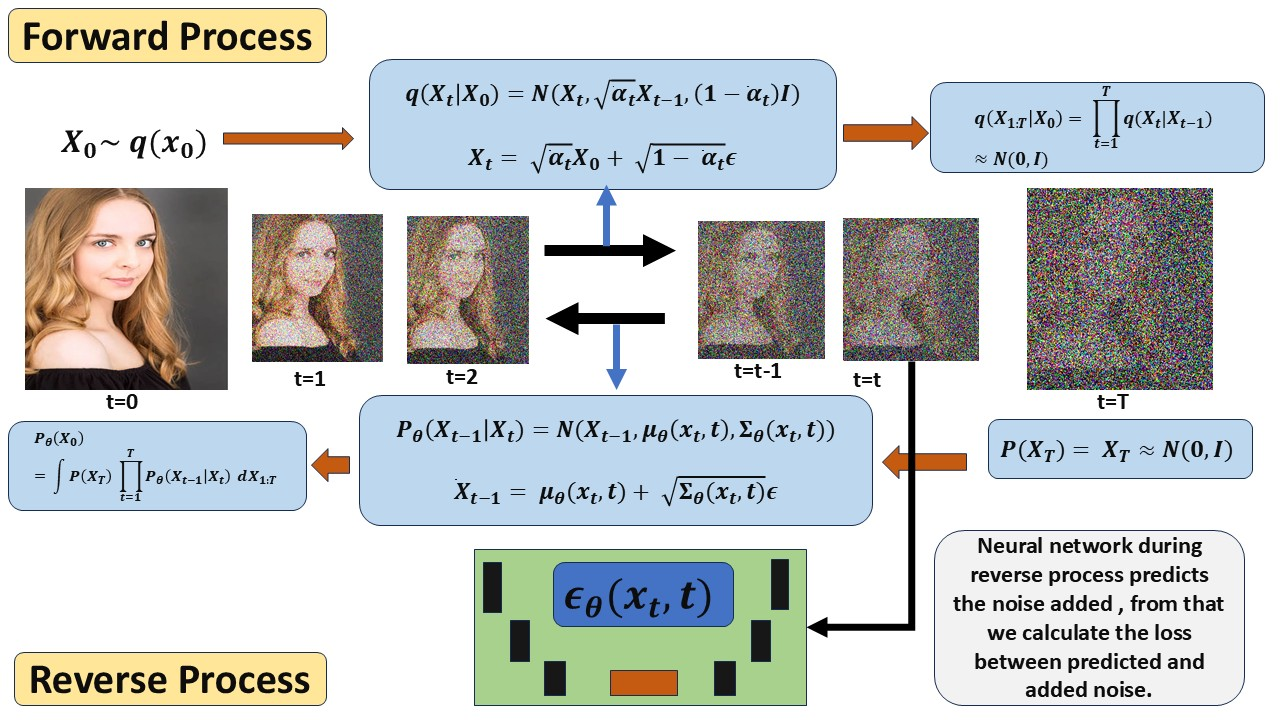

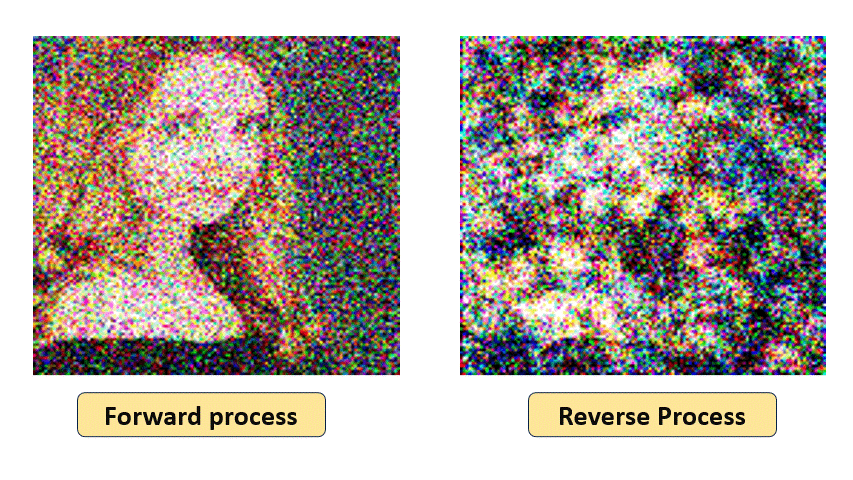

# **LET US LOAD AND UNDERSTAND THE DATA**

# **Create PSI-PHI LABELLED DATA**

In [ ]:
import os
import numpy as np

# Example:
# data = np.loadtxt("")
# data.shape = (50000, 38)

num_pairs = 19
output_dir = "psi_phi_data"
os.makedirs(output_dir, exist_ok=True)

for i in range(num_pairs):
    psi = data[:, 2 * i]
    phi = data[:, 2 * i + 1]
    pair_data = np.column_stack((psi, phi))

    # Create label row
    labels = np.array([[f"psi{i+1}", f"phi{i+1}"]], dtype=str)

    # Stack labels + numeric data (convert all to str for uniform dtype)
    full_data = np.vstack((labels, pair_data.astype(str)))

    # Save as .npy
    filename = os.path.join(output_dir, f"psi_phi_{i+1}.npy")
    np.save(filename, full_data)
    print(f" Saved: {filename}  shape={full_data.shape}")

print("\nAll ψ–φ data files saved as .npy with label row included!")


 Saved: psi_phi_data/psi_phi_1.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_2.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_3.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_4.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_5.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_6.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_7.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_8.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_9.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_10.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_11.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_12.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_13.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_14.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_15.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_16.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_17.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_18.npy  shape=(50001, 2)
 Saved: psi_phi_data/psi_phi_19.npy  

# **IMPORT LIBRARIES**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# **SET DEVICE**

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
#device = "cuda:0"
print("Using device:", device)

Using device: cpu


#  **Diffusion Schedule**


**Diffusion Model Definitions**

Beta schedule:
$$
\beta_t \in (0,1), \qquad t = 1,2,\ldots,T
$$

Alpha:
$$
\alpha_t = 1 - \beta_t
$$

Cumulative product:
$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$



In [ ]:
# ======================================
#  2. Diffusion Schedule
# ======================================
T = 1000  # total diffusion steps
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)


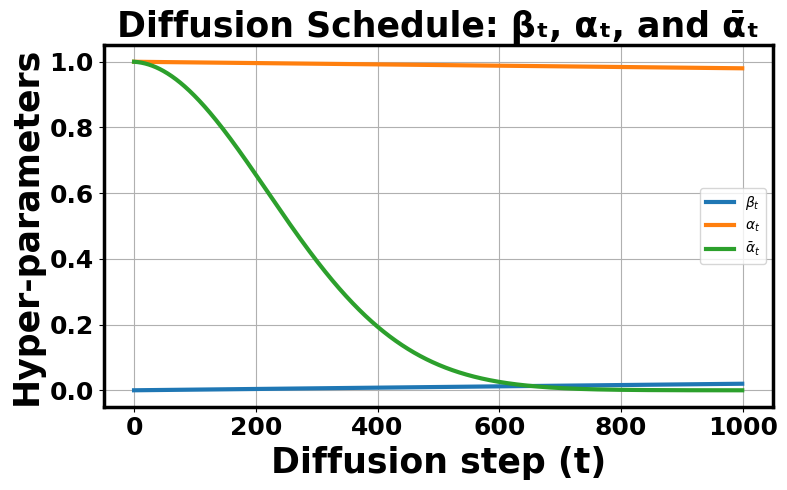

In [ ]:
# ==========================
# Plot
# ==========================
plt.figure(figsize=(8, 5))

plt.plot(range(T), betas.cpu(), label=r'$\beta_t$', lw=3)
plt.plot(range(T), alphas.cpu(), label=r'$\alpha_t$', lw=3)
plt.plot(range(T), alpha_bars.cpu(), label=r'$\bar{\alpha}_t$', lw=3)

plt.xlabel("Diffusion step (t)", fontweight="bold", fontsize=25)
plt.ylabel("Hyper-parameters",  fontweight="bold", fontsize=25)
plt.title("Diffusion Schedule: βₜ, αₜ, and ᾱₜ", fontweight="bold", fontsize=25)
plt.xticks(fontsize=18, fontweight="bold")
plt.yticks(fontsize=18, fontweight="bold")
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("diffusion_hyper_param.png")
plt.show()


#   **Time Embedding**


In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear1 = nn.Linear(1, dim)
        self.linear2 = nn.Linear(dim, dim)

    def forward(self, t):
        #print("Input t shape:", t.shape)
        t = t.unsqueeze(-1).float() / T
        #print("After unsqueeze & normalize:", t.shape)
        t = F.relu(self.linear1(t))
        #print("After linear1 + ReLU:", t.shape)
        t = self.linear2(t)
        #print("After linear2:", t.shape)
        return t

# **Example for time embedding input**

In [ ]:

batch_size = 4
timesteps = torch.randint(0, T, (batch_size,))  # random timesteps [0, T)
print("Shape of timesteps:",timesteps.shape)
print("Timesteps",timesteps)
time_emb_output = TimeEmbedding(dim=256)

# Forward pass
out = time_emb_output(timesteps)
print("\nFinal output shape:", out.shape)
print("\nFinal time embeddings :", out)

Shape of timesteps: torch.Size([4])
Timesteps tensor([868, 335, 460, 982])

Final output shape: torch.Size([4, 256])

Final time embeddings : tensor([[ 0.3469,  0.0015,  0.1759,  ..., -0.0413,  0.1529,  0.3517],
        [ 0.2190,  0.1327,  0.1235,  ..., -0.0954,  0.0988,  0.3921],
        [ 0.2439,  0.0875,  0.1469,  ..., -0.0762,  0.1188,  0.3717],
        [ 0.3821,  0.0063,  0.1735,  ..., -0.0316,  0.1568,  0.3452]],
       grad_fn=<AddmmBackward0>)


# **Conditional MLP-Unet**

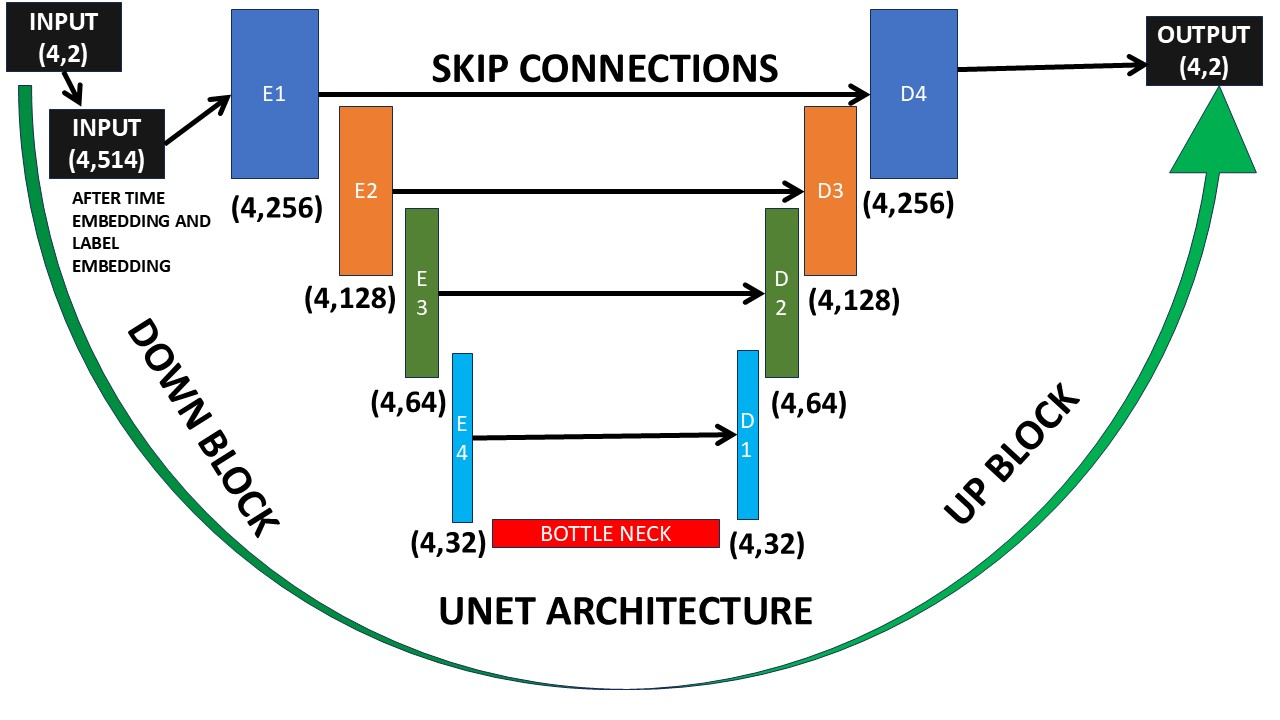

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConditionalUNet(nn.Module):
    def __init__(self, data_dim=2, cond_dim=19, hidden_dim=256):
        super().__init__()
        self.time_embed = TimeEmbedding(hidden_dim)
        self.cond_embed = nn.Embedding(cond_dim, hidden_dim)

        # Down Block
        self.fc1 = nn.Linear(data_dim + hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.fc4 = nn.Linear(hidden_dim // 4, hidden_dim // 8)

        # Bottleneck
        self.bottle_neck = nn.Linear(hidden_dim // 8, hidden_dim // 8)

        # Up Block
        self.fc5 = nn.Linear(hidden_dim // 8, hidden_dim // 4)
        self.fc6 = nn.Linear(hidden_dim // 4, hidden_dim // 2)
        self.fc7 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t, cond_idx, return_hidden=False):
        # Time embedding
        t_emb = self.time_embed(t)

        # Conditional label embedding
        c_emb = self.cond_embed(cond_idx)

        # Concatenate the input
        input_vec = torch.cat([x, t_emb, c_emb], dim=-1)

        # Encoder
        e1 = F.relu(self.fc1(input_vec))
        e2 = F.relu(self.fc2(e1))
        e3 = F.relu(self.fc3(e2))
        e4 = F.relu(self.fc4(e3))

        # Bottleneck
        bottle_neck = F.relu(self.bottle_neck(e4))

        # Decoder
        d1 = F.relu(self.fc5(bottle_neck))
        d1 = d1 + e3 # Skip connection
        d2 = F.relu(self.fc6(d1))
        d2 = d2 + e2 # Skip connection
        d3 = F.relu(self.fc7(d2))
        d3 = d3 + e1 # Skip connection
        d4 = self.fc8(d3)

        out = d4

        if return_hidden:
            return out, t_emb, c_emb, e1, e2, e3, e4, bottle_neck, d1, d2, d3, d4
        return out



In [ ]:


# ==============================
# Example Run
# ==============================
T = 1000
batch_size = 4
data_dim = 2
cond_dim = 19
hidden_dim = 256

x = torch.randn(batch_size, data_dim)
t = torch.randint(0, T, (batch_size,))
cond_idx = torch.randint(0, cond_dim, (batch_size,))

model = ConditionalUNet(data_dim, cond_dim, hidden_dim)
out, t_emb, c_emb, e1, e2, e3, e4, bottle_neck, d1, d2, d3, d4 = model(x, t, cond_idx, return_hidden=True)

print("Shapes summary:")
print("====================================================================================")
print("Input x       :", x.shape, " → original input data (2D)")
print("Time embed    :", t_emb.shape, " → time embedding (256D)")
print("Cond embed    :", c_emb.shape, " → condition embedding (256D)")
print("\n")
print("============== DOWN BLOCK ============================================================")
print("Hidden 1 (e1) :", e1.shape)
print("Hidden 2 (e2) :", e2.shape)
print("Hidden 3 (e3) :", e3.shape)
print("Hidden 4 (e4) :", e4.shape)
print("====================================================================================")

print("\n")
print("============== BOTTLE NECK ========================================================")
print("Bottleneck    :", bottle_neck.shape)
print("====================================================================================")


print("\n")
print("============== UPBLOCK ============================================================")
print("Decoder 1 (d1):", d1.shape)
print("Decoder 2 (d2):", d2.shape)
print("Decoder 3 (d3):", d3.shape)
print("Output        :", out.shape, " → final output (2D)")
print("====================================================================================")

Shapes summary:
Input x       : torch.Size([4, 2])  → original input data (2D)
Time embed    : torch.Size([4, 256])  → time embedding (256D)
Cond embed    : torch.Size([4, 256])  → condition embedding (256D)


============== DOWN BLOCK ============================================================
Hidden 1 (e1) : torch.Size([4, 256])
Hidden 2 (e2) : torch.Size([4, 128])
Hidden 3 (e3) : torch.Size([4, 64])
Hidden 4 (e4) : torch.Size([4, 32])


============== BOTTLE NECK ========================================================
Bottleneck    : torch.Size([4, 32])


============== UPBLOCK ============================================================
Decoder 1 (d1): torch.Size([4, 64])
Decoder 2 (d2): torch.Size([4, 128])
Decoder 3 (d3): torch.Size([4, 256])
Output        : torch.Size([4, 2])  → final output (2D)


# **LOAD OUR PSI PHI LABELLED DATA ...............**

In [ ]:
data_dict = {}
for i in range(19):
    arr = np.load(f"psi_phi_data/psi_phi_{i+1}.npy", allow_pickle=True)

    # If the first row has strings (like ['psi1', 'phi1']), skip it
    if isinstance(arr[0, 0], str):
        arr = arr[1:, :]

    # Convert to float
    arr = arr.astype(np.float32)

    data_dict[i] = arr
    print(f"Loaded ψ–φ pair {i+1}: {data_dict[i].shape}, dtype={data_dict[i].dtype}")

Loaded ψ–φ pair 1: (50000, 2), dtype=float32
Loaded ψ–φ pair 2: (50000, 2), dtype=float32
Loaded ψ–φ pair 3: (50000, 2), dtype=float32
Loaded ψ–φ pair 4: (50000, 2), dtype=float32
Loaded ψ–φ pair 5: (50000, 2), dtype=float32
Loaded ψ–φ pair 6: (50000, 2), dtype=float32
Loaded ψ–φ pair 7: (50000, 2), dtype=float32
Loaded ψ–φ pair 8: (50000, 2), dtype=float32
Loaded ψ–φ pair 9: (50000, 2), dtype=float32
Loaded ψ–φ pair 10: (50000, 2), dtype=float32
Loaded ψ–φ pair 11: (50000, 2), dtype=float32
Loaded ψ–φ pair 12: (50000, 2), dtype=float32
Loaded ψ–φ pair 13: (50000, 2), dtype=float32
Loaded ψ–φ pair 14: (50000, 2), dtype=float32
Loaded ψ–φ pair 15: (50000, 2), dtype=float32
Loaded ψ–φ pair 16: (50000, 2), dtype=float32
Loaded ψ–φ pair 17: (50000, 2), dtype=float32
Loaded ψ–φ pair 18: (50000, 2), dtype=float32
Loaded ψ–φ pair 19: (50000, 2), dtype=float32


# **FORWARD PROCESS .......(q_sample)**

**Diffusion Model Definitions**

Beta schedule:
$$
\beta_t \in (0,1), \qquad t = 1,2,\ldots,T
$$

Alpha:
$$
\alpha_t = 1 - \beta_t
$$

Cumulative product:
$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$



Forward noising distribution:
$$
q(\mathbf{x}_t \mid \mathbf{x}_0)
= \mathcal{N}\!\left(
\sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\;
(1-\bar{\alpha}_t)\,\mathbf{I}
\right)
$$

Reparameterized forward process:
$$
\mathbf{x}_t =
\sqrt{\bar{\alpha}_t}\, \mathbf{x}_0
+ \sqrt{1-\bar{\alpha}_t}\, \boldsymbol{\epsilon},
\qquad
\boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{I})
$$


# **Forward Diffusion Process — Full Derivation**

We start with a Markov chain that gradually adds Gaussian noise to an initial data point.

---

## **1. Forward transition distribution**

At each timestep we define:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}\!\left(
\sqrt{\alpha_t}\, x_{t-1},\;
(1 - \alpha_t)\, I
\right)
$$

where:

$$
\alpha_t = 1 - \beta_t.
$$

---

## **2. Expand the first steps**

For \(t = 1\):

$$
x_1 = \sqrt{\alpha_1}\, x_0
      + \sqrt{1-\alpha_1}\,\epsilon_1
$$

For \(t = 2\):

$$
x_2 = \sqrt{\alpha_2}\, x_1
      + \sqrt{1-\alpha_2}\,\epsilon_2
$$

Substitute \(x_1\):

$$
x_2 =
\sqrt{\alpha_2 \alpha_1}\, x_0
+
\sqrt{\alpha_2(1-\alpha_1)}\,\epsilon_1
+
\sqrt{1-\alpha_2}\,\epsilon_2
$$

We already see the pattern:  
each step multiplies the previous mean by $$ \sqrt{\alpha_t} $$.

---

## **3. General pattern and cumulative product**

Define the cumulative product:

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$

Then the deterministic part of \(x_t\) becomes:

$$
\sqrt{\bar{\alpha}_t}\, x_0.
$$

---

## **4. Combine all Gaussian noise terms**

Each timestep adds Gaussian noise scaled by earlier \(\alpha\)'s.  
Since a sum of Gaussian noises is Gaussian, we combine them into a single term:

$$
\sqrt{1 - \bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

---

## **5. Final closed-form forward diffusion process**

Thus:

$$
x_t =
\sqrt{\bar{\alpha}_t}\, x_0
+
\sqrt{1 - \bar{\alpha}_t}\, \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I)
$$

Equivalently:

$$
q(x_t \mid x_0)
=
\mathcal{N}\!\left(
\sqrt{\bar{\alpha}_t}\,x_0,\;
(1 - \bar{\alpha}_t)\,I
\right)
$$


In [ ]:
def q_sample(x0, t, noise):
    sqrt_alpha_bar = alpha_bars[t] ** 0.5
    sqrt_one_minus = (1 - alpha_bars[t]) ** 0.5
    return sqrt_alpha_bar.view(-1, 1) * x0 + sqrt_one_minus.view(-1, 1) * noise


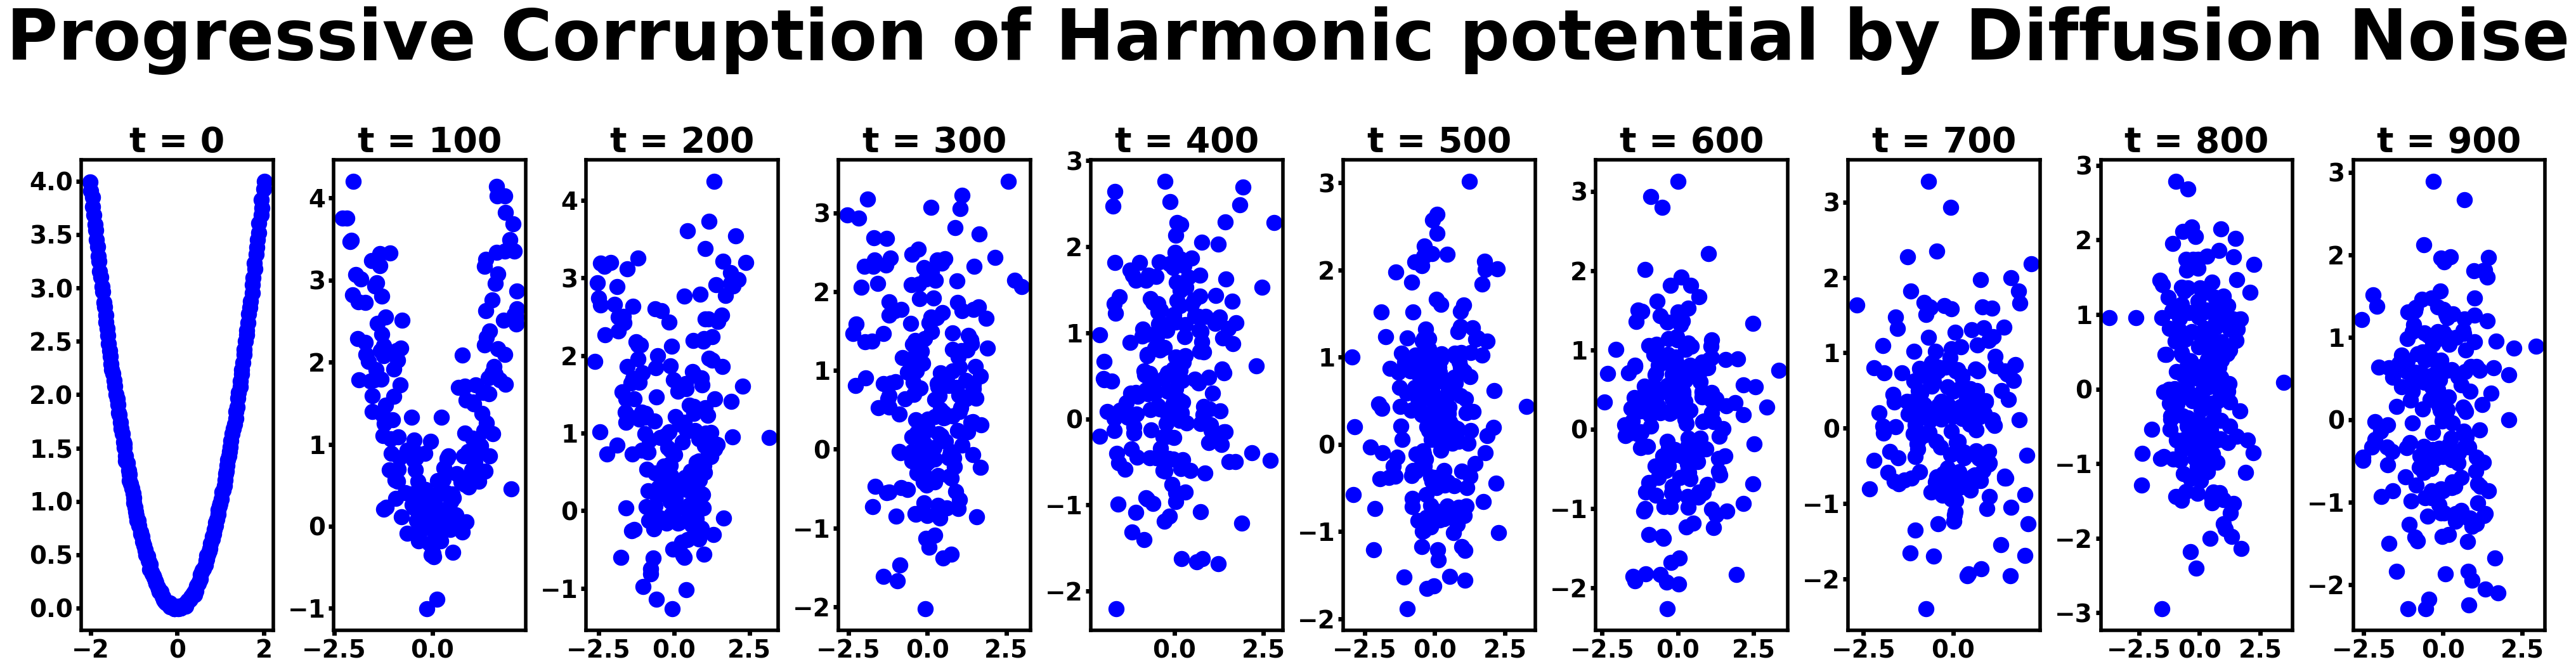

In [ ]:

# ===============================
# Diffusion schedule
# ===============================
T = 1000 # total timesteps
betas = torch.linspace(1e-4, 0.02, T).to(device)# total timesteps
# ===============================
# Parabola as initial data
# ===============================
x = torch.linspace(-2, 2, 200).unsqueeze(1)
y = x**2
x0 = torch.cat([x, y], dim=1)  # shape [200, 2]

# ===============================
# Generate noisy samples
# ===============================
fig, axes = plt.subplots(1,10, figsize=(40, 10))
axes = axes.flatten()


for i, t in enumerate(range(0,T,100)):
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    ax = axes[i]
    ax.scatter(xt[:, 0], xt[:, 1], s=300, color='blue', alpha=1.0)
    ax.set_title(f"t = {t}", fontsize=40, fontweight="bold")
    # Bold tick labels
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")

    ax.tick_params(axis='both', labelsize=28, width=5, length=6)

     # BOLD BOARDERS
    for spine in ax.spines.values():
        spine.set_linewidth(4)

    #ax.set_xlim(-2.5, 2.5)
    #ax.set_ylim(-0.5, 4.5)
    ax.axis('on')

plt.suptitle("Progressive Corruption of Harmonic potential by Diffusion Noise",
             fontsize=80, fontweight="bold", y=1.05)

plt.tight_layout()
plt.savefig("Forward_process.png")
plt.show()


# **INITIALIZE THE MODEL WITH OPTIMIZER ......**

In [ ]:
EPOCHS = 100
BATCH_SIZE = 32
save_dir = "checkpoints_ddpm"
os.makedirs(save_dir, exist_ok=True)
model = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# **DDPM Training Objective: Noise Prediction View**

During training, diffusion models learn to **predict the noise** that was added to a clean sample.  
This is the key insight behind the simplified DDPM loss.

---

## **1. Forward noising**

We sample a clean data point:

$$
x_0 \sim q(x_0)
$$

Choose a random timestep:

$$
t \sim \text{Uniform}(\{1,\ldots,T\})
$$

Add noise using the forward process:

From the forward process:

$$
x_t - \sqrt{\bar{\alpha}_t}\, x_0
=
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I)
$$

Solving for the noise:

$$
\epsilon
=
\frac{
x_t - \sqrt{\bar{\alpha}_t}\, x_0
}{
\sqrt{1 - \bar{\alpha}_t}
}
$$


Here, **we know the exact noise** $\epsilon$ because *we added it ourselves*.

---

## **2. Model predicts the noise**

The neural network $ \epsilon_\theta(x_t, t) $ takes the noised sample $x_{t}$ and timestep $t$,  
and its goal is to predict the original noise $\epsilon$ that was injected.

---

## **3. The DDPM training loss**

The training loss is simply:

$$
\mathcal{L}_{\text{simple}}
=
\mathbb{E}_{x_0, t, \epsilon}
\left[
\left\|
\epsilon - \epsilon_\theta(x_t, t)
\right\|^2
\right]
$$

This means:

- **we generate $x_t$** using known noise  
- **we ask the model to reconstruct that noise**  
- **we minimize the difference between the true noise and predicted noise**

---

## **4. Why this works**

Predicting noise is equivalent to predicting the score $\nabla_{x_t} \log q(x_t)$,  
which in turn is equivalent to modeling the reverse diffusion process.
**Tweedie's Formula**
Thus, the entire DDPM training reduces to:

> **“Given a noisy sample $x_t$, predict the noise that was used to create it.”**

This is the core training mechanism that allows the model to learn how to denoise at every timestep.


# **SINCE LIVE TRAINING FOR TRPCAGE IS DIFFICULT , WE WILL TRAIN IT ON SYNTHETIC Harmonic Potential DATA ......**

In [ ]:
# ===============================
# Generate Parabola Data (multi-condition)
# ===============================
def generate_parabola_data(n_points=500, conds=5):
    data_dict = {}
    for cond_idx in range(conds):
        x = torch.linspace(-2, 2, n_points)
        # Different shapes for each condition
        a = 0.5 + 0.2 * cond_idx  # curvature
        b = 0.1 * cond_idx        # shift
        y = a * x**2 + b
        xy = torch.stack([x, y], dim=1)
        data_dict[cond_idx] = xy
    return data_dict

data_dict = generate_parabola_data()

# **FULLY COMBINED ONE CODE FOR TRAINING ON Harmonic potential DATA ......................**

In [ ]:
import torch
import numpy as np
import os
import torch.nn.functional as F
import torch.nn as nn

# ===============================
# CONFIG
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 1000
BATCH_SIZE = 128
save_dir = "checkpoints_PARABOLA"
os.makedirs(save_dir, exist_ok=True)

# ===============================
# Diffusion schedule
# ===============================
beta_start, beta_end = 0.0001, 0.02
T=1000
betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    sqrt_alpha_bar = alpha_bars[t] ** 0.5
    sqrt_one_minus = (1 - alpha_bars[t]) ** 0.5
    # broadcasting over batch
    return sqrt_alpha_bar.view(-1, 1) * x0 + sqrt_one_minus.view(-1, 1) * noise

# ===============================
# Conditional U-Net (Simple MLP)
# ===============================
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear1 = nn.Linear(1, dim)
        self.linear2 = nn.Linear(dim, dim)
    def forward(self, t):
        t = t.float().unsqueeze(1)
        return F.relu(self.linear2(F.relu(self.linear1(t))))

class ConditionalUNet(nn.Module):
    def __init__(self, data_dim=2, cond_dim=5, hidden_dim=128, dropout_prob=0.1):
        super().__init__()
        self.time_embed = TimeEmbedding(hidden_dim)
        self.cond_embed = nn.Embedding(cond_dim, hidden_dim)
        self.fc1 = nn.Linear(data_dim + hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, data_dim)
        self.dropout1 = nn.Dropout(dropout_prob)  # Dropout after fc1
        self.dropout2 = nn.Dropout(dropout_prob)  # Dropout after fc2
    def forward(self, x, t, cond_idx):
        t_emb = self.time_embed(t)
        c_emb = self.cond_embed(cond_idx)
        h = torch.cat([x, t_emb, c_emb], dim=-1)

        h = F.relu(self.fc1(h))
        #h = self.dropout1(h)

        h = F.relu(self.fc2(h))
        #h = self.dropout2(h)

        return self.fc3(h)

# ===============================
# Model + Optimizer
# ===============================
data_dim = 2
cond_dim = len(data_dict)
hidden_dim = 128
model = ConditionalUNet(data_dim, cond_dim, hidden_dim, dropout_prob=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===============================
# Training Loop
# ===============================
losses = []
for epoch in range(EPOCHS):
    total_loss = 0
    model.train()

    for cond_idx, data in data_dict.items():
        x0 = data.to(device)
        n_samples = x0.shape[0]

        perm = torch.randperm(n_samples)
        for i in range(0, n_samples, BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            batch = x0[idx]
            bsz = batch.shape[0]


            t = torch.randint(0, T, (bsz,), device=device)
            noise = torch.randn_like(batch)

            # ADDING NOISE
            xt = q_sample(batch, t, noise)

            cond_tensor = torch.full((bsz,), cond_idx, dtype=torch.long, device=device)
            pred_noise = model(xt, t, cond_tensor)

            loss = F.mse_loss(pred_noise, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    avg_loss = total_loss / len(data_dict)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Average Loss: {avg_loss:.6f}")

    if (epoch + 1) % 100 == 0:
        ckpt_path = os.path.join(save_dir, f"ddpm_epoch_{epoch+1:03d}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }, ckpt_path)
        print(f"Saved checkpoint: {ckpt_path}")


Epoch [1/1000] - Average Loss: 41.172017
Epoch [2/1000] - Average Loss: 5.469913
Epoch [3/1000] - Average Loss: 4.212794
Epoch [4/1000] - Average Loss: 3.913455
Epoch [5/1000] - Average Loss: 4.504442
Epoch [6/1000] - Average Loss: 4.233988
Epoch [7/1000] - Average Loss: 4.315179
Epoch [8/1000] - Average Loss: 3.880896
Epoch [9/1000] - Average Loss: 4.202990
Epoch [10/1000] - Average Loss: 3.987106
Epoch [11/1000] - Average Loss: 3.810511
Epoch [12/1000] - Average Loss: 3.948493
Epoch [13/1000] - Average Loss: 3.801997
Epoch [14/1000] - Average Loss: 3.659926
Epoch [15/1000] - Average Loss: 3.748460
Epoch [16/1000] - Average Loss: 3.704926
Epoch [17/1000] - Average Loss: 3.600236
Epoch [18/1000] - Average Loss: 3.368164
Epoch [19/1000] - Average Loss: 3.298509
Epoch [20/1000] - Average Loss: 3.256625
Epoch [21/1000] - Average Loss: 3.299243
Epoch [22/1000] - Average Loss: 3.122058
Epoch [23/1000] - Average Loss: 3.191027
Epoch [24/1000] - Average Loss: 3.041704
Epoch [25/1000] - Averag

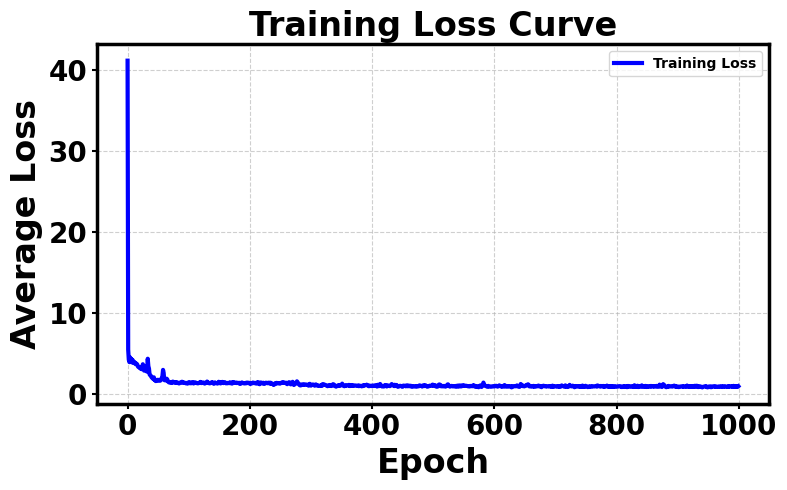

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losses,label=r'Training Loss', color='blue', linewidth=3)
plt.xlabel('Epoch', fontsize=24, fontweight="bold")
plt.ylabel('Average Loss', fontsize=24,fontweight="bold")
plt.title('Training Loss Curve', fontsize=24,fontweight="bold")
# Bold ticks
plt.xticks(fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")

# Bold borders
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20, prop={'weight':'bold'})
plt.tight_layout()
plt.savefig("Loss.png")
plt.show()


In [ ]:
print(cond_dim)
print(n_samples)
print(bsz)
print(t.shape)
print(t)
print(cond_tensor.shape)
print(cond_tensor)
print("\n")
print("Input to model shape :",xt.shape)
print("output of model shape :",pred_noise.shape)

5
500
116
torch.Size([116])
tensor([209, 729, 306, 672, 946, 815, 535, 471, 669, 651,  29, 604, 519, 884,
        238, 662, 443, 636,  88, 858, 168, 417, 447, 153,  43, 891, 616, 299,
        179,  31, 972, 749, 148, 114, 587, 886, 530, 574, 468, 959, 512, 990,
        391, 310, 273, 655, 327, 960, 515,  36, 643, 570, 138, 116, 124, 165,
        321, 197, 346, 819, 985, 476, 388, 421, 285, 322, 358, 663, 184, 934,
        835, 342, 401, 461, 227, 886, 733, 510,  71, 310, 858, 321, 269, 518,
        553, 943, 305, 292, 585, 228,  28, 656, 374,  15, 278, 618, 226, 732,
        494, 246, 267, 549, 684, 990, 606, 738, 531, 691, 564,  64, 863, 383,
        565,   9, 161, 148])
torch.Size([116])
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

# **======================================**
#  **Reverse Process (Sampling)**
# **======================================**

# **Reverse Diffusion Sampling (DDPM) — Posterior Sampling**

During sampling, we start from pure noise $x_T \sim \mathcal{N}(0, I) $
and iteratively denoise using the learned model.

At each reverse step $t \rightarrow t-1$, the model predicts the noise
$\epsilon_\theta(x_t, t)$, which is used to approximate the DDPM reverse mean.

---

## **1. Model predicts the noise at timestep \(t\)**

$$
\epsilon_\theta(x_t, t)
\approx
\epsilon
$$

This is the noise that was added during the forward process.

---

## **2. Reverse mean (DDPM posterior mean)**

The DDPM paper derives that the mean of $q(x_{t-1} \mid x_t, x_0)$
can be written purely in terms of the predicted noise.

The expression used in your code is:

$$
\mu_t(x_t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}}
\, \epsilon_\theta(x_t, t)
\right)
$$

This is exactly the **reverse denoising step**.

---

## **3. Add randomness (except at the final step)**

For \(t > 0\), the reverse process is stochastic:

$$
x_{t-1}
=
\mu_t(x_t)
+
\sqrt{\beta_t}\, z,
\qquad
z \sim \mathcal{N}(0, I)
$$

The term $\sqrt{\beta_t}$ is the variance of the reverse transition.

Thus the full update is:

$$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}}
\, \epsilon_\theta(x_t, t)
\right)
+
\sqrt{\beta_t}\, z
$$

---

## **4. Final step \(t = 0\) is deterministic**

Because at the final step we do not add any noise:

$$
x_0 = \mu_1(x_1)
$$

This produces the clean sample.

---

## **Overall flow**

- The model predicts the noise at timestep \(t\).  
- We plug this into the DDPM reverse mean formula.  
- We sample from the reverse Gaussian transition using variance $beta_t$.  
- At $t = 0$, no more noise is added → final generated output.


In [ ]:
# ======================================
#  8. Reverse Process (Sampling)
# ======================================
@torch.no_grad()
def sample(model, cond_idx, n_samples=5000):
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    cond_tensor = torch.full((n_samples,), cond_idx, dtype=torch.long, device=device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device)
        pred_noise = model(x, t_tensor, cond_tensor)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        # Compute the mean term for DDPM reverse process
        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        # Add noise except at t=0
        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean  # last step: deterministic output

    return x.cpu().numpy()


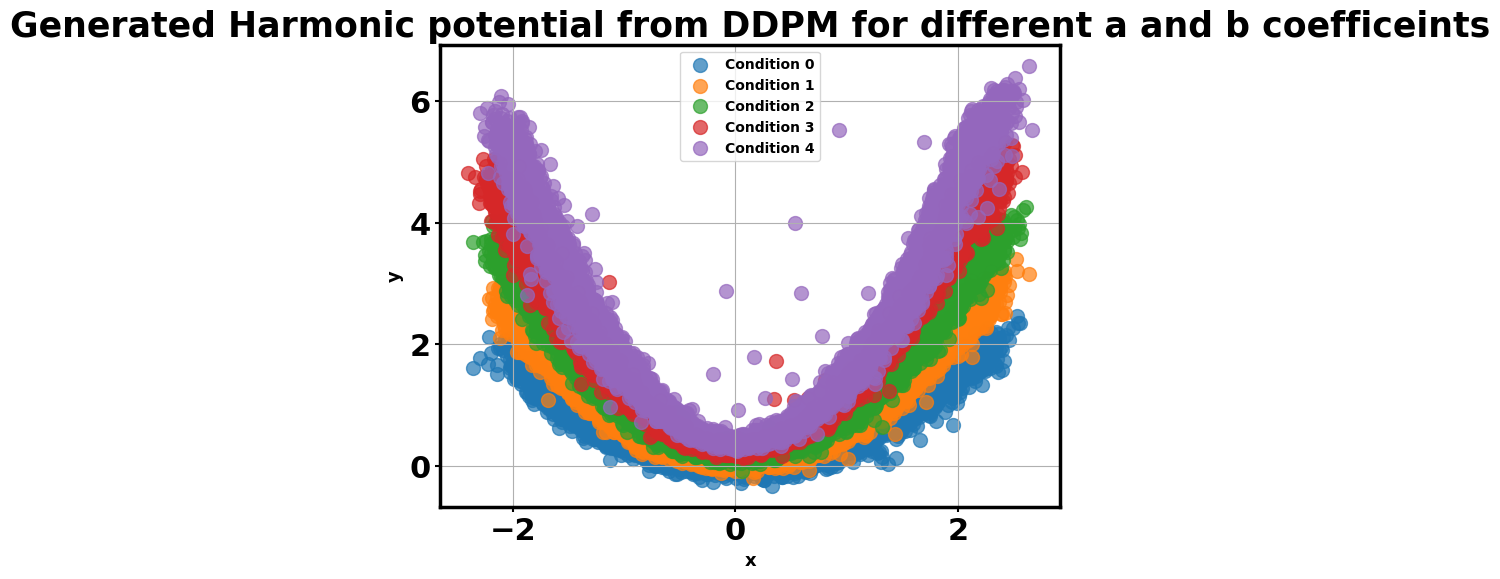

In [ ]:
import matplotlib.pyplot as plt

# Generate 5 parabolas from conditions 0, 1,2,3, 4
plt.figure(figsize=(8, 6))
for cond_idx in [0,1,2,3,4]:
    samples = sample(model, cond_idx, n_samples=5000)
    plt.scatter(samples[:, 0], samples[:, 1], s=100, label=f"Condition {cond_idx}", alpha=0.7)

plt.title("Generated Harmonic potential from DDPM for different a and b coefficeints", fontweight="bold",fontsize=25,)
plt.xlabel("x")
plt.ylabel("y")
#plt.xlim(-2,2)
#plt.ylim(0,4)
# Bold ticks
plt.xticks(fontsize=22, fontweight="bold")
plt.yticks(fontsize=22, fontweight="bold")

# Bold borders
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.5)
plt.legend(fontsize=30, prop={'weight':'bold'})
plt.grid(True)
plt.savefig("Conditional_Generation_for_various_a_b.png")
plt.show()


# **Showing the Reverse process**

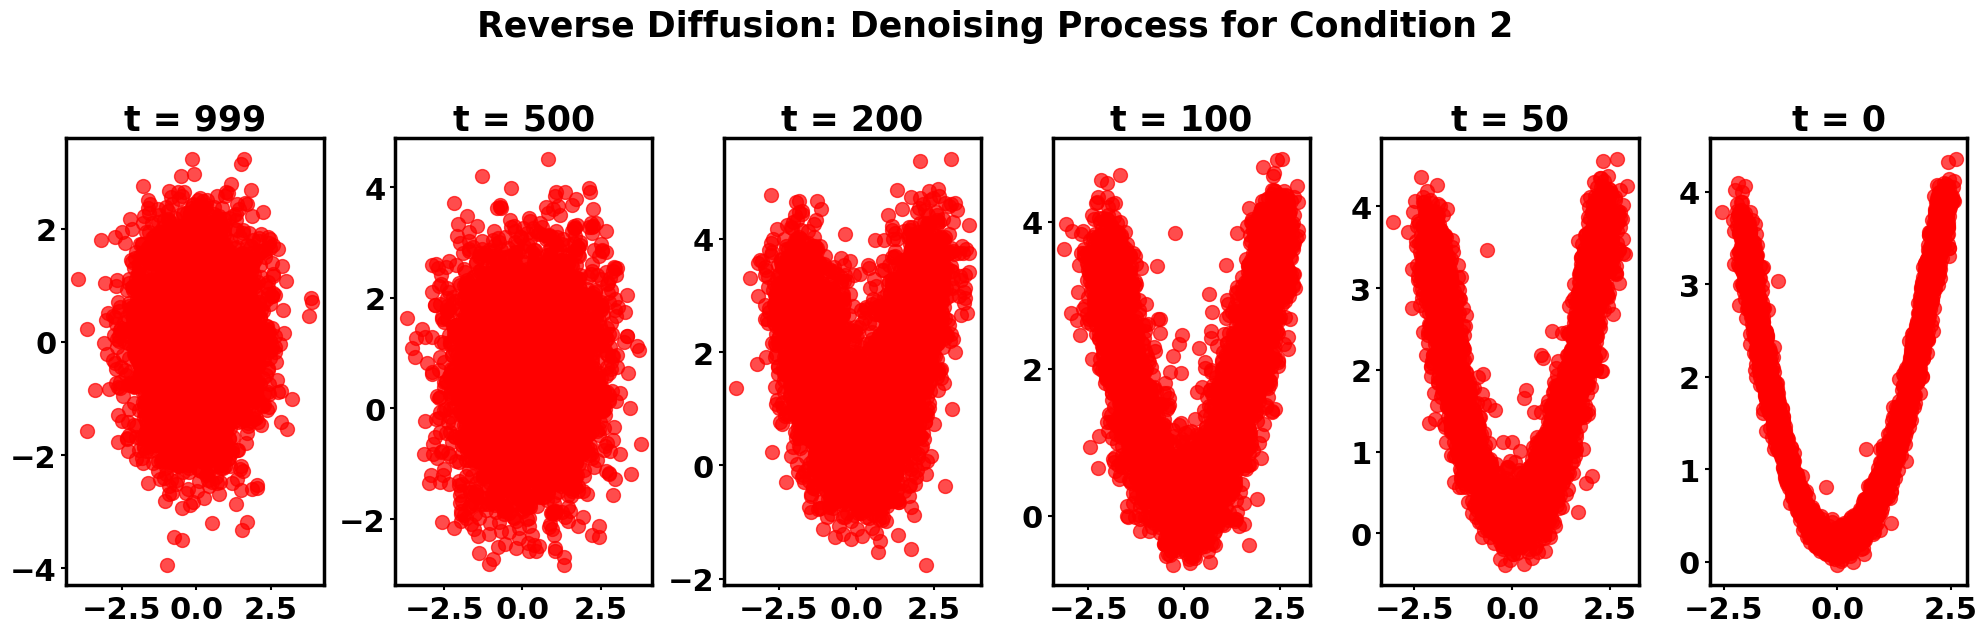

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_with_snapshots(model, cond_idx, n_samples=5000, steps_to_save=[1000, 750, 500, 250, 0]):
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    cond_tensor = torch.full((n_samples,), cond_idx, dtype=torch.long, device=device)

    snapshots = {}
    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device)
        pred_noise = model(x, t_tensor, cond_tensor)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

        # Save snapshot if t is close to one of the selected steps
        if t in steps_to_save:
            snapshots[t] = x.detach().cpu().numpy()

    return snapshots

# ===============================================
# Visualize denoising process for a given condition
# ===============================================
cond_idx = 2
snapshots = sample_with_snapshots(model, cond_idx, n_samples=5000, steps_to_save=[999, 500,200, 100, 50, 0])

plt.figure(figsize=(20, 6))
for i, (t, data) in enumerate(sorted(snapshots.items(), reverse=True)):
    plt.subplot(1, len(snapshots), i + 1)
    plt.scatter(data[:, 0], data[:, 1], s=100, alpha=0.7,color="red")
    plt.title(f"t = {t}", fontweight="bold", fontsize=25)
    #plt.xlim(-2, 2)
    #plt.ylim(0, 4)
    #plt.grid(True)
    # Bold ticks
    plt.xticks(fontsize=22, fontweight="bold")
    plt.yticks(fontsize=22, fontweight="bold")

    # Bold borders
    for spine in plt.gca().spines.values():
        spine.set_linewidth(2.5)

plt.suptitle(
    f"Reverse Diffusion: Denoising Process for Condition {cond_idx}",
    fontsize=25,        # Larger font
    fontweight="bold",  # Bold text
    y=1.05 ,# Adds space above plots for wide title

)
plt.tight_layout()
plt.savefig("Generated_during_training.png")
plt.show()


# **GENERATE FROM A SAVED MODEL**

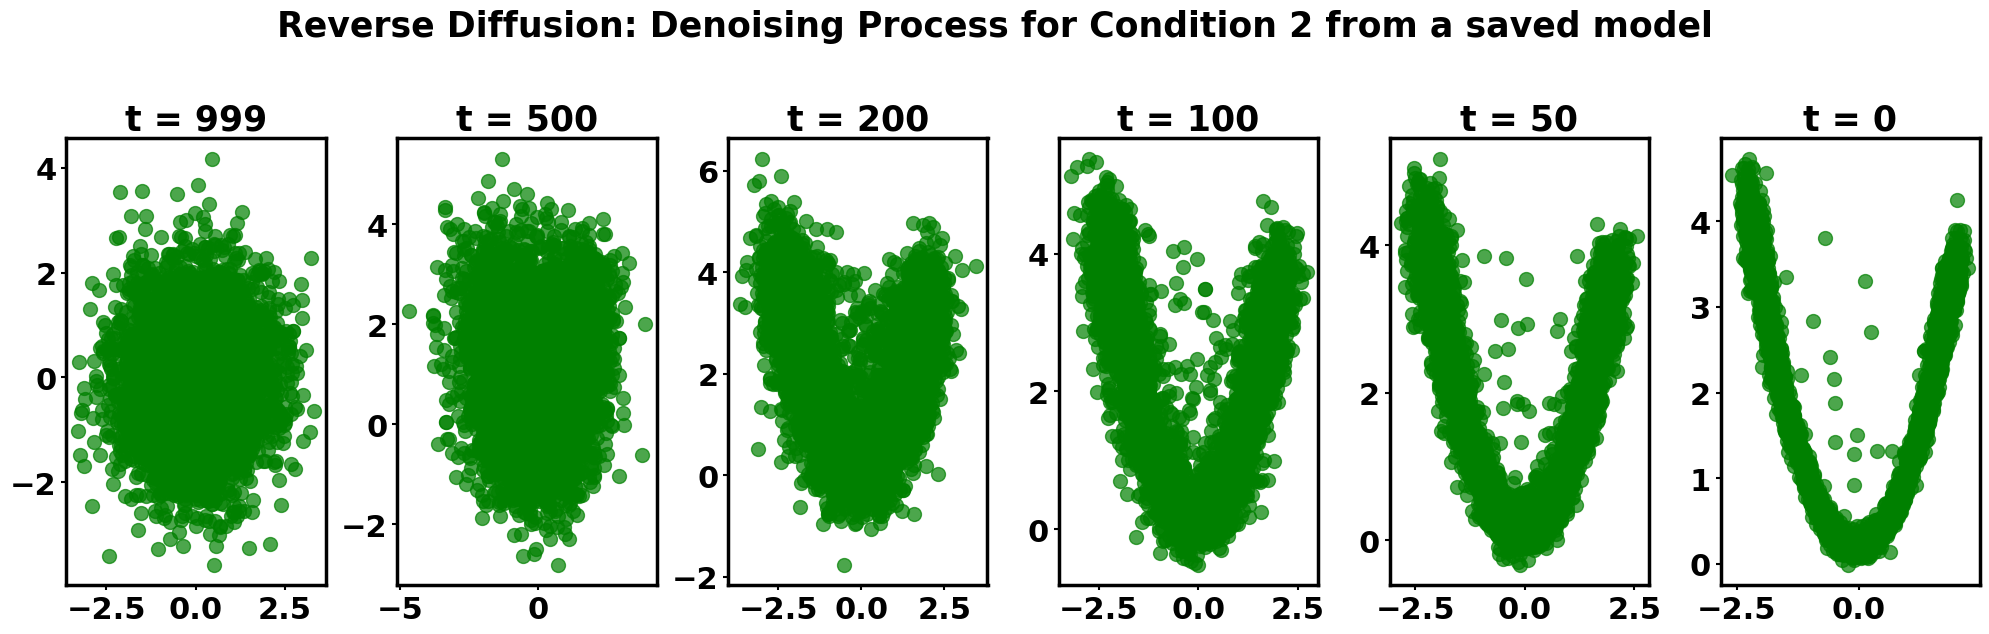

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_with_snapshots(model, cond_idx, n_samples=5000, steps_to_save=[1000, 750, 500, 250, 0]):
    model = ConditionalUNet(data_dim, cond_dim, hidden_dim).to(device)
    checkpoint = torch.load("checkpoints_PARABOLA/ddpm_epoch_900.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    cond_tensor = torch.full((n_samples,), cond_idx, dtype=torch.long, device=device)

    snapshots = {}
    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device)
        pred_noise = model(x, t_tensor, cond_tensor)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

        # Save snapshot if t is close to one of the selected steps
        if t in steps_to_save:
            snapshots[t] = x.detach().cpu().numpy()

    return snapshots

# ===============================================
# Visualize denoising process for a given condition
# ===============================================
cond_idx = 2
snapshots = sample_with_snapshots(model, cond_idx, n_samples=5000, steps_to_save=[999, 500,200, 100, 50, 0])

plt.figure(figsize=(20, 6))
for i, (t, data) in enumerate(sorted(snapshots.items(), reverse=True)):
    plt.subplot(1, len(snapshots), i + 1)
    plt.scatter(data[:, 0], data[:, 1], s=100, alpha=0.7,color="green")
    plt.title(f"t = {t}", fontweight="bold", fontsize=25)
    #plt.xlim(-2, 2)
    #plt.ylim(0, 4)
    #plt.grid(True)
    # Bold ticks
    plt.xticks(fontsize=22, fontweight="bold")
    plt.yticks(fontsize=22, fontweight="bold")

    # Bold borders
    for spine in plt.gca().spines.values():
        spine.set_linewidth(2.5)

plt.suptitle(
    f"Reverse Diffusion: Denoising Process for Condition {cond_idx} from a saved model",
    fontsize=25,        # Larger font
    fontweight="bold",  # Bold text
    y=1.05 ,# Adds space above plots for wide title

)
plt.tight_layout()
plt.savefig("GENERATED_FROM_SAVED_MODEL.png")
plt.show()


# **Derivation of the DDPM Reverse Mean**

We start from the forward diffusion process:

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

Rearranging gives the noise:

$$
\epsilon
=
\frac{x_t - \sqrt{\bar{\alpha}_t}\, x_0}{\sqrt{1 - \bar{\alpha}_t}}.
$$

---

## **Posterior distribution**

The forward posterior is Gaussian:

$$
q(x_{t-1} \mid x_t, x_0)
=
\mathcal{N}\!\left(
\mu_t(x_t, x_0),\;
\tilde{\beta}_t I
\right),
$$

with true posterior mean:

$$
\mu_t(x_t,x_0)
=
\frac{
\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})\, x_0
+
\sqrt{\bar{\alpha}_{t-1}}\,\beta_t\, x_t
}{
1 - \bar{\alpha}_t
}.
$$

---

## **Replace unknown $x_0$ with predicted noise**

From the forward equation:

$$
x_0
=
\frac{
x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon
}{
\sqrt{\bar{\alpha}_t}
}.
$$

During sampling the model predicts noise:

$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

So we estimate:

$$
x_0 \approx
\frac{
x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)
}{
\sqrt{\bar{\alpha}_t}
}.
$$

---

## **Final DDPM reverse mean (used in code)**

Substituting gives:

$$
\mu_t(x_t,\epsilon_\theta)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\epsilon_\theta(x_t,t)
\right).
$$

---

## **Reverse sampling**

For $t > 0$:

$$
x_{t-1}
=
\mu_t(x_t,\epsilon_\theta)
+
\sqrt{\beta_t}\, z,
\qquad
z \sim \mathcal{N}(0, I).
$$

For $t = 0$:

$$
x_0 = \mu_t(x_t,\epsilon_\theta).
$$




## ================================**THE END**===================================

# RECTIFIED FLOW

# Rectified Flow – Mathematical Formulation

## Goal

Learn a deterministic mapping from noise to data:

$$
x_0 \sim p_0(x), \quad x_1 \sim p_{\text{data}}(x)
$$

We want to construct a flow:

$$
x(0) = x_0 \rightarrow x(1) = x_1
$$

---

## Linear Interpolation Path

Define a straight-line path between noise and data:

$$
x_t = (1 - t)\, x_0 + t\, x_1, \quad t \in [0,1]
$$

---

## True Velocity Field

Differentiate w.r.t. time:

$$
\frac{d x_t}{dt} = x_1 - x_0
$$

So the **target velocity** is:

$$
v^*(x_t, t) = x_1 - x_0
$$

---

## Model

We learn a neural network:

$$
v_\theta(x, t) \approx v^*(x, t)
$$

---

## Training Objective (Flow Matching)

$$
\mathcal{L}(\theta) = \mathbb{E}_{x_0, x_1, t} 
\left[ 
\left\| v_\theta(x_t, t) - (x_1 - x_0) \right\|^2 
\right]
$$

where:
- $x_0 \sim \mathcal{N}(0, I)$  
- $x_1 \sim p_{\text{data}}(x)$  
- $t \sim \mathcal{U}(0,1)$  

---

---

## Inference (Sampling)

$$
\frac{dx}{dt} = v_\theta(x, t)
$$

with initial condition:

$$
x(0) \sim \mathcal{N}(0, I)
$$

---

## Numerical Integration (Euler)

$$
x_{t+\Delta t} = x_t + v_\theta(x_t, t)\, \Delta t
$$

---

## Conditional Rectified Flow

$$
v_\theta(x, t, c)
$$

$$
\mathcal{L}(\theta) = \mathbb{E}_{x_0, x_1, t, c}
\left[
\left\| v_\theta(x_t, t, c) - (x_1 - x_0) \right\|^2
\right]
$$

---

## Summary

$$
\boxed{
\frac{dx}{dt} = v_\theta(x,t)
}
$$

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================
# CONFIG
# ============================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 5000
LR = 1e-3



In [17]:

# ============================================
# DATA
# ============================================
def generate_parabola_data(n_points=500, conds=5):
    data_dict = {}
    for cond_idx in range(conds):
        x = torch.linspace(-2, 2, n_points)
        a = 0.5 + 0.2 * cond_idx
        b = 0.1 * cond_idx
        y = a * x**2 + b
        xy = torch.stack([x, y], dim=1)
        data_dict[cond_idx] = xy
    return data_dict


data_dict = generate_parabola_data()


In [18]:

def sample_batch(batch_size):
    x_list, c_list = [], []

    for _ in range(batch_size):
        cond = torch.randint(0, len(data_dict), (1,))
        curve = data_dict[cond.item()]

        idx = torch.randint(0, curve.shape[0], (1,))
        point = curve[idx].squeeze(0)

        x_list.append(point)
        c_list.append(cond)

    x1 = torch.stack(x_list).to(DEVICE)
    c = torch.stack(c_list).long().to(DEVICE)

    return x1, c

In [15]:
# ============================================
# TIME EMBEDDING
# ============================================
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        return self.net(t)

In [16]:

# ============================================
# MODEL 
# ============================================
class ConditionalUNet(nn.Module):
    def __init__(self, data_dim=2, cond_dim=5, hidden_dim=256):
        super().__init__()
        self.time_embed = TimeEmbedding(hidden_dim)
        self.cond_embed = nn.Embedding(cond_dim, hidden_dim)

        self.fc1 = nn.Linear(data_dim + hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.fc4 = nn.Linear(hidden_dim // 4, hidden_dim // 8)

        self.bottle_neck = nn.Linear(hidden_dim // 8, hidden_dim // 8)

        self.fc5 = nn.Linear(hidden_dim // 8, hidden_dim // 4)
        self.fc6 = nn.Linear(hidden_dim // 4, hidden_dim // 2)
        self.fc7 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t, cond_idx):
        t_emb = self.time_embed(t)
        #c_emb = self.cond_embed(cond_idx)
        c_emb = self.cond_embed(cond_idx.squeeze(-1))

        input_vec = torch.cat([x, t_emb, c_emb], dim=-1)

        e1 = F.relu(self.fc1(input_vec))
        e2 = F.relu(self.fc2(e1))
        e3 = F.relu(self.fc3(e2))
        e4 = F.relu(self.fc4(e3))

        bottle_neck = F.relu(self.bottle_neck(e4))

        d1 = F.relu(self.fc5(bottle_neck))
        d1 = d1 + e3
        d2 = F.relu(self.fc6(d1))
        d2 = d2 + e2
        d3 = F.relu(self.fc7(d2))
        d3 = d3 + e1
        d4 = self.fc8(d3)

        return d4


In [19]:
# ============================================
# TRAIN STEP
# ============================================
def train_step(model, optimizer):
    x1, cond = sample_batch(BATCH_SIZE)

    x0 = torch.randn_like(x1)
    t = torch.rand(BATCH_SIZE, 1).to(DEVICE)

    xt = (1 - t) * x0 + t * x1
    target = x1 - x0

    pred = model(xt, t, cond)

    loss = ((pred - target) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [39]:
# ============================================
# SAMPLING
# ============================================
@torch.no_grad()
def sample(model, cond_idx, num_samples=5000, steps=200):
    x = torch.randn(num_samples, 2).to(DEVICE)
    cond = torch.full((num_samples,), cond_idx, dtype=torch.long).to(DEVICE)

    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((num_samples, 1), i / steps).to(DEVICE)
        v = model(x, t, cond)
        x = x + v * dt

    return x.cpu()

In [33]:
import os
import matplotlib.pyplot as plt

os.makedirs("checkpoints_flow", exist_ok=True)

loss_history = []

print("Training...")

for epoch in range(EPOCHS):
    loss = train_step(model, optimizer)
    loss_history.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

    # ============================================
    # SAVE CHECKPOINT
    # ============================================
    if epoch % 500 == 0 and epoch > 0:
        save_path = f"checkpoints_flow/model_epoch_{epoch}.pt"

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'loss_history': loss_history,  
        }, save_path)

        print(f"Saved checkpoint at {save_path}")

    # ============================================
    # PLOT LOSS
    # ============================================
    if epoch % 200 == 0 and epoch > 0:
        plt.figure()
        plt.plot(loss_history)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.grid()

        plot_path = f"checkpoints_flow/loss_epoch_{epoch}.png"
        plt.savefig(plot_path)
        plt.close()

        print(f"Saved loss plot at {plot_path}")

Training...
Epoch 0, Loss: 1.440090
Epoch 100, Loss: 1.534844
Epoch 200, Loss: 1.481048
Saved loss plot at checkpoints_flow/loss_epoch_200.png
Epoch 300, Loss: 1.641778
Epoch 400, Loss: 1.560542
Saved loss plot at checkpoints_flow/loss_epoch_400.png
Epoch 500, Loss: 1.484418
Saved checkpoint at checkpoints_flow/model_epoch_500.pt
Epoch 600, Loss: 1.487726
Saved loss plot at checkpoints_flow/loss_epoch_600.png
Epoch 700, Loss: 1.438562
Epoch 800, Loss: 1.462808
Saved loss plot at checkpoints_flow/loss_epoch_800.png
Epoch 900, Loss: 1.446096
Epoch 1000, Loss: 1.238286
Saved checkpoint at checkpoints_flow/model_epoch_1000.pt
Saved loss plot at checkpoints_flow/loss_epoch_1000.png
Epoch 1100, Loss: 1.293820
Epoch 1200, Loss: 1.514232
Saved loss plot at checkpoints_flow/loss_epoch_1200.png
Epoch 1300, Loss: 1.541144
Epoch 1400, Loss: 1.293096
Saved loss plot at checkpoints_flow/loss_epoch_1400.png
Epoch 1500, Loss: 1.627413
Saved checkpoint at checkpoints_flow/model_epoch_1500.pt
Epoch 1600

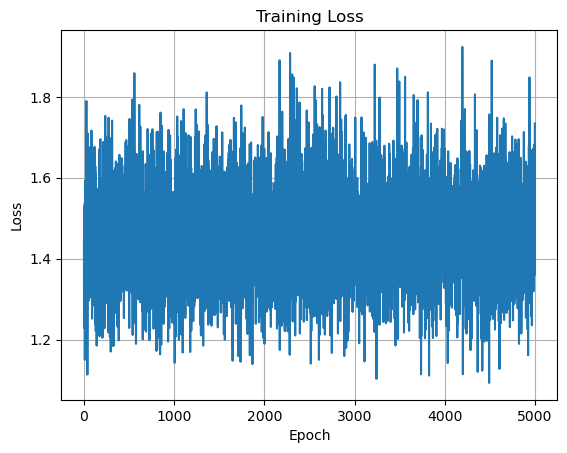

Saved loss plot at checkpoints_flow/final_loss.png


In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()

plot_path = "checkpoints_flow/final_loss.png"
plt.savefig(plot_path)
plt.show()

print(f"Saved loss plot at {plot_path}")

In [36]:

# ============================================
# PLOT
# ============================================
def plot_condition(model, cond_idx):
    samples = sample(model, cond_idx).numpy()
    true_curve = data_dict[cond_idx].numpy()

    plt.figure(figsize=(5,5))
    plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.4, label="Generated")
    plt.plot(true_curve[:,0], true_curve[:,1], color='red', label="True")
    plt.title(f"Condition {cond_idx}")
    plt.legend()
    plt.grid()
    plt.show()

Final results


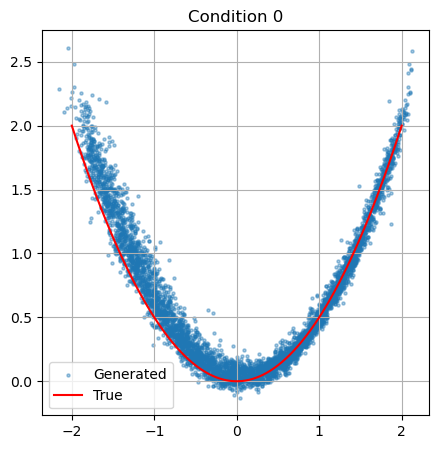

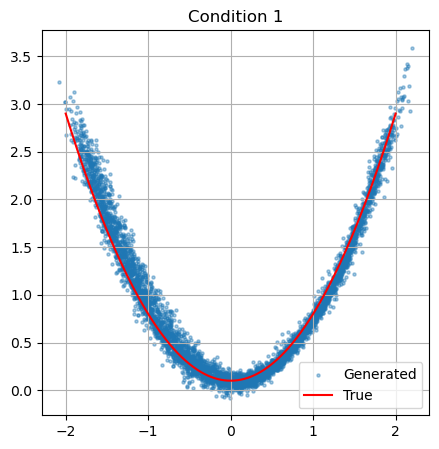

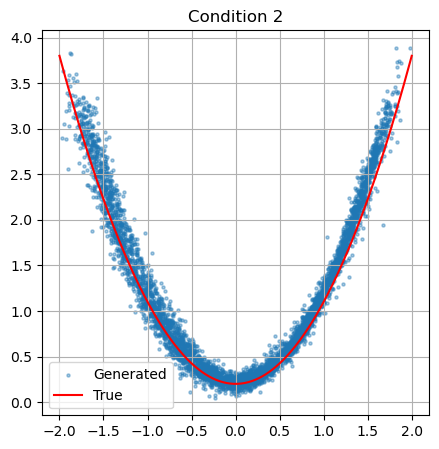

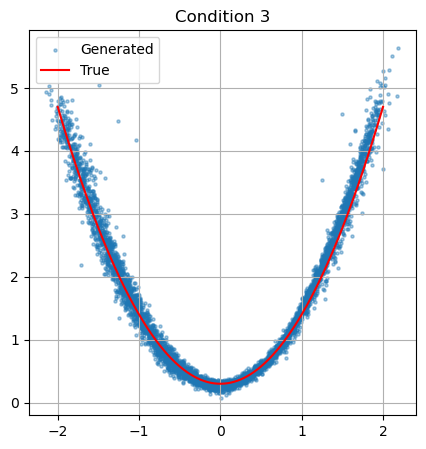

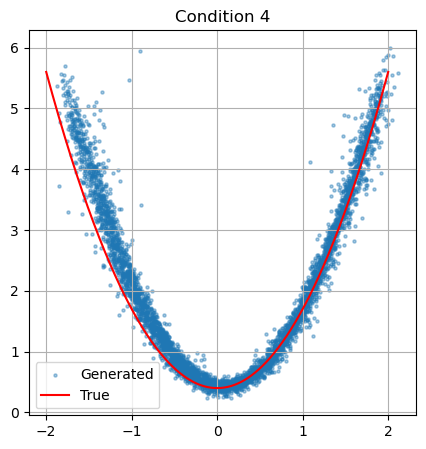

In [40]:

# ============================================
# FINAL
# ============================================
print("Final results")
for cond in range(5):
    plot_condition(model, cond)

/tmp/ipykernel_460208/2267760245.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoints_flow/model_epoch_4500.pt", map_location=DEVICE)


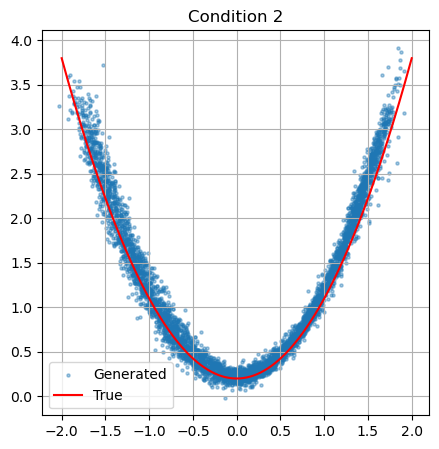

In [41]:
# model
model = ConditionalUNet().to(DEVICE)

# load checkpoint
checkpoint = torch.load("checkpoints_flow/model_epoch_4500.pt", map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])


model.eval()  


# sample

plot_condition(model, cond_idx=2)

In [42]:
@torch.no_grad()
def sample_trajectory(model, cond_idx, num_samples=500, steps=100):
    x = torch.randn(num_samples, 2).to(DEVICE)
    cond = torch.full((num_samples,), cond_idx, dtype=torch.long).to(DEVICE)

    traj = []  # store trajectory
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((num_samples, 1), i / steps).to(DEVICE)

        traj.append(x.detach().cpu())  # store current state

        v = model(x, t, cond)
        x = x + v * dt

    traj.append(x.detach().cpu())  # final state

    return traj

In [43]:
import matplotlib.pyplot as plt

def plot_trajectory_subplots(traj, cond_idx):
    num_frames = len(traj)
    indices = torch.linspace(0, num_frames-1, steps=6).long()  # pick 6 frames

    plt.figure(figsize=(12, 2))

    for i, idx in enumerate(indices):
        plt.subplot(1, 6, i+1)

        data = traj[idx].numpy()
        plt.scatter(data[:,0], data[:,1], s=5, alpha=0.5)

        plt.title(f"t={idx.item()/num_frames:.2f}")
        plt.xticks([])
        plt.yticks([])

    plt.suptitle(f"Time Evolution (cond={cond_idx})")
    plt.tight_layout()
    plt.show()

In [58]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch

def create_gif(traj, cond_idx, data_dict):
    os.makedirs("gifs", exist_ok=True)

    images = []

    # get true curve
    true_curve = data_dict[cond_idx].numpy()

    for i, frame in enumerate(traj):
        data = frame.numpy()

        fig, ax = plt.subplots(figsize=(4,4))

        # generated samples
        ax.scatter(data[:,0], data[:,1], s=5, alpha=0.5, label="Generated")

        # true parabola
        ax.plot(true_curve[:,0], true_curve[:,1], color='red', linewidth=2, label="True")

        ax.set_title(f"t = {i/len(traj):.2f}")
        ax.set_xlim(-3, 3)
        ax.set_ylim(-1, 5)
        ax.legend()
        ax.grid()

        temp_path = f"gifs/frame_{i}.png"
        fig.savefig(temp_path)
        plt.close(fig)

        images.append(Image.open(temp_path))

    gif_path = f"gifs/flow_cond_{cond_idx}.gif"

    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=50,
        loop=0
    )

    print(f"Saved GIF at {gif_path}")

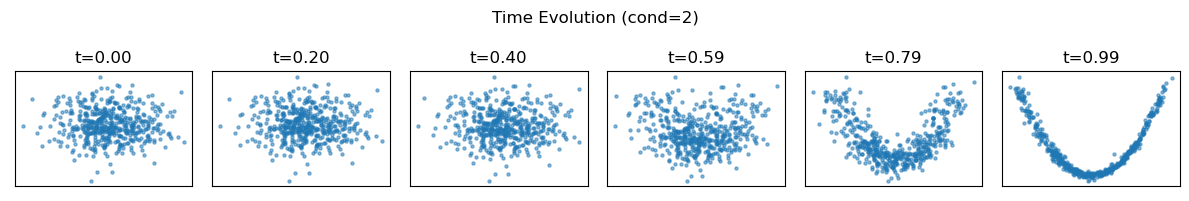

Saved GIF at gifs/flow_cond_2.gif


In [62]:
traj = sample_trajectory(model, cond_idx=2, steps=100)

plot_trajectory_subplots(traj, cond_idx=2)


create_gif(traj, cond_idx=2, data_dict=data_dict)

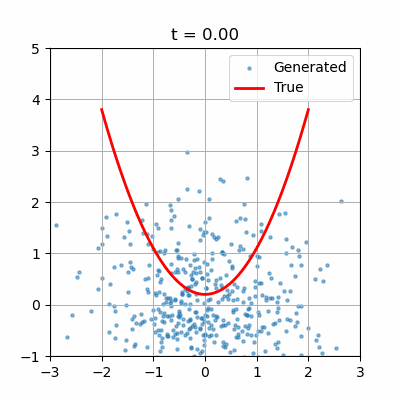

In [63]:
cond_idx = 2
gif_path = f"gifs/flow_cond_{cond_idx}.gif"
from IPython.display import Image as IPImage, display

display(IPImage(filename=gif_path))